In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="J8ItSDl4jJiLpWxFoWat")
project = rf.workspace("roboflow-jvuqo").project("tft-id-mgv7w")
version = project.version(2)
dataset = version.download("yolov11")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 38.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to TFT-ID-2 in yolov11:: 100%|██████████| 17166/17166 [00:19<00:00, 879.15it/s]  


In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [3]:
!pip install ultralytics supervision
import ultralytics
ultralytics.checks()

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 50.7/112.6 GB disk)


In [5]:
from ultralytics import YOLO
from PIL import Image
import requests
model = YOLO('yolo11n.pt')
image = Image.open("/content/Screenshot 2026-05-19 184620.png")
results = model.predict(image,conf=0.25)[0]


0: 160x640 (no detections), 86.9ms
Speed: 26.2ms preprocess, 86.9ms inference, 6.1ms postprocess per image at shape (1, 3, 160, 640)


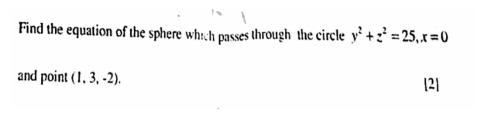

In [8]:
plt.figure(figsize=(6, 4))
plt.imshow(results.plot())
plt.axis("off")
plt.show()



In [9]:
results.boxes.xyxy

tensor([], device='cuda:0', size=(0, 4))

In [10]:
results.boxes.conf

tensor([], device='cuda:0')

In [11]:
image = Image.open("/content/download.jpg")
results = model.predict(image,conf=0.25)[0]


0: 352x640 1 dog, 53.6ms
Speed: 1.9ms preprocess, 53.6ms inference, 33.1ms postprocess per image at shape (1, 3, 352, 640)


In [12]:
import cv2
import matplotlib.pyplot as plt

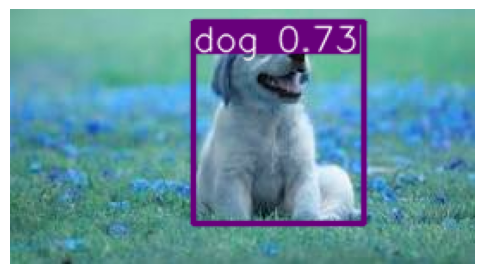

In [13]:
plt.figure(figsize=(6, 4))
plt.imshow(results.plot())
plt.axis("off")
plt.show()



In [14]:
dataset.location

'/content/TFT-ID-2'

In [15]:
%cd {HOME}

!yolo task=detect mode=train \
mode=train\
model=yolo11n.pt \
data={dataset.location}/data.yaml \
epochs=5 \
imgsz=640 \
plots=True

/content
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/TFT-ID-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

In [16]:
%cd {HOME}

!yolo task=detect mode=train \
mode=train\
model=yolo11n.pt \
data={dataset.location}/data.yaml \
epochs=10 \
imgsz=640 \
plots=True

/content
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/TFT-ID-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

The YOLO11n model achieved excellent document layout detection performance with:
- Precision: 93.6%
- Recall: 93.1%
- mAP50: 97.0%
- mAP50-95: 92.9%

The model can accurately detect text, tables, and figures and is ready for OCR-based document understanding tasks.

In [17]:
!ls {HOME}/runs/detect/train/


args.yaml			 labels.jpg		val_batch0_pred.jpg
BoxF1_curve.png			 results.csv		val_batch1_labels.jpg
BoxP_curve.png			 results.png		val_batch1_pred.jpg
BoxPR_curve.png			 train_batch0.jpg	val_batch2_labels.jpg
BoxR_curve.png			 train_batch1.jpg	val_batch2_pred.jpg
confusion_matrix_normalized.png  train_batch2.jpg	weights
confusion_matrix.png		 val_batch0_labels.jpg


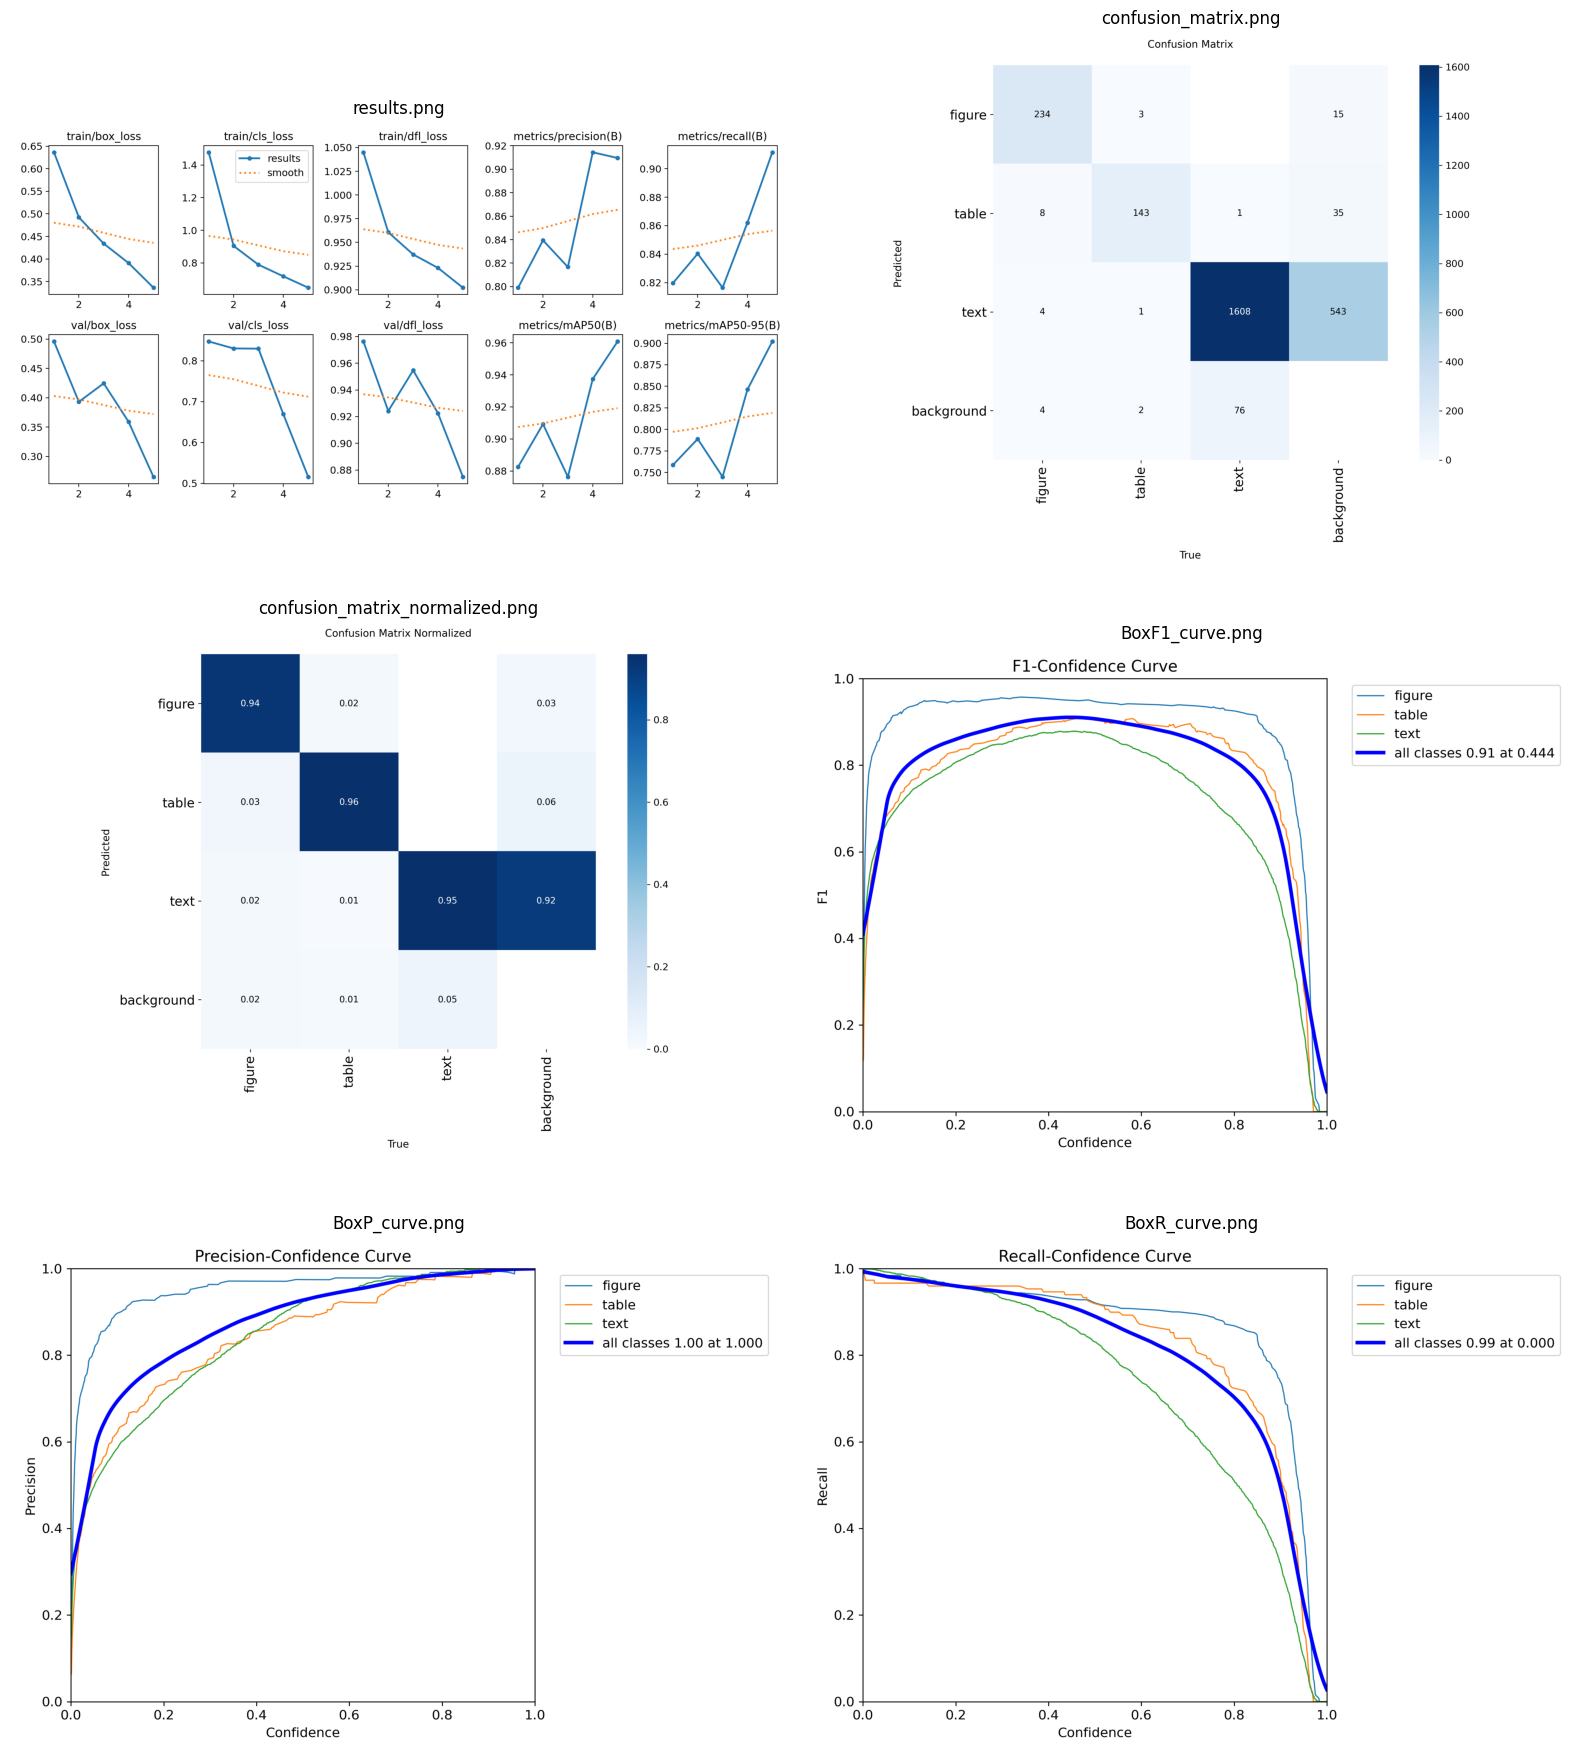

In [18]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

files = [
    "/content/runs/detect/train/results.png",
    "/content/runs/detect/train/confusion_matrix.png",
    "/content/runs/detect/train/confusion_matrix_normalized.png",
    "/content/runs/detect/train/BoxF1_curve.png",
    "/content/runs/detect/train/BoxP_curve.png",
    "/content/runs/detect/train/BoxR_curve.png",
]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for ax, file in zip(axes.ravel(), files):
    img = mpimg.imread(file)
    ax.imshow(img)
    ax.set_title(file.split("/")[-1], fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


0: 640x576 1 figure, 4 texts, 51.3ms
Speed: 4.9ms preprocess, 51.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 576)


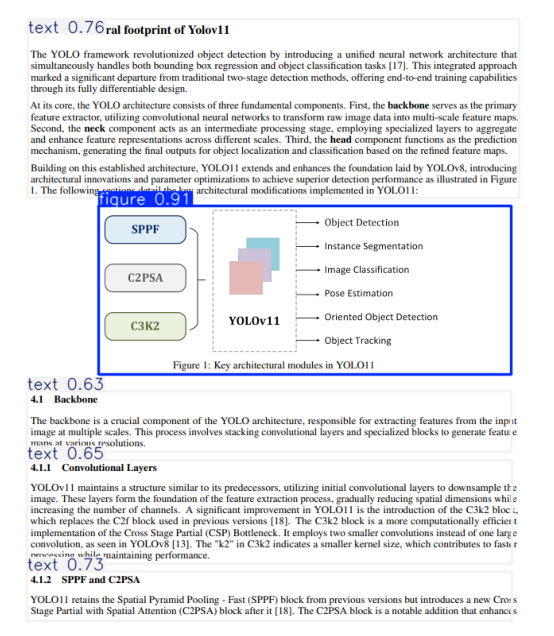

Number of detections: 5

Class: figure, Confidence: 0.91, Box: [111, 246, 630, 458]
Class: text, Confidence: 0.76, Box: [22, 11, 640, 236]
Class: text, Confidence: 0.73, Box: [21, 706, 631, 768]
Class: text, Confidence: 0.65, Box: [21, 566, 631, 696]
Class: text, Confidence: 0.63, Box: [21, 479, 630, 555]


In [19]:

# Load trained model
model = YOLO("/content/runs/detect/train-2/weights/best.pt")

# Load image
image_path = "/content/Screenshot 2026-06-02 172844.png"
image = cv2.imread(image_path)

# Run prediction
results = model.predict(image, conf=0.5)[0]

# Draw boxes and labels on image
annotated_image = results.plot()

# Convert BGR -> RGB for matplotlib
annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

# Display image
plt.figure(figsize=(12,8))
plt.imshow(annotated_image)
plt.axis("off")
plt.show()

# Print detection details
print(f"Number of detections: {len(results.boxes)}\n")

for box in results.boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])

    x1, y1, x2, y2 = box.xyxy[0].tolist()

    print(
        f"Class: {model.names[cls_id]}, "
        f"Confidence: {conf:.2f}, "
        f"Box: [{int(x1)}, {int(y1)}, {int(x2)}, {int(y2)}]"
    )

In [21]:
cv2.imwrite("output.jpg", annotated_image)

True